# Aerial Object Classification (Bird vs Drone)

**Goal:** Classify aerial images as **Bird** or **Drone** using a Custom CNN and a Transfer Learning model (MobileNetV2), compare them, and save the best model for Streamlit deployment.

**Expected dataset structure:**
```
classification_dataset/
├── train/
│   ├── bird/
│   └── drone/
├── valid/
│   ├── bird/
│   └── drone/
└── test/
    ├── bird/
    └── drone/
```


## 1. Imports & Setup

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "classification_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
TEST_DIR  = os.path.join(DATA_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["bird", "drone"]

os.makedirs("models", exist_ok=True)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.18.0


## 2. Understand the Dataset
- Inspect folder structure
- Count images per class
- Check class imbalance
- Visualize sample images

In [2]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return counts

for split, path in [("TRAIN", TRAIN_DIR), ("VALID", VALID_DIR), ("TEST", TEST_DIR)]:
    print(f"{split}: {count_images(path)}")


TRAIN: {'bird': 1414, 'drone': 1248}
VALID: {'bird': 217, 'drone': 225}
TEST: {'bird': 121, 'drone': 94}


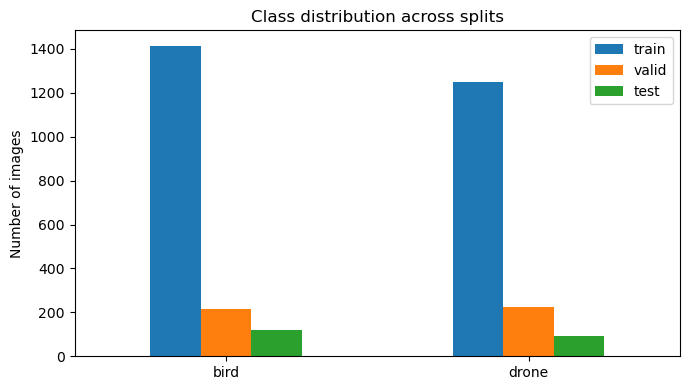

In [3]:
splits = {"train": TRAIN_DIR, "valid": VALID_DIR, "test": TEST_DIR}
df_counts = pd.DataFrame({s: count_images(p) for s, p in splits.items()}).fillna(0)
df_counts.plot(kind="bar", figsize=(7, 4))
plt.title("Class distribution across splits")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


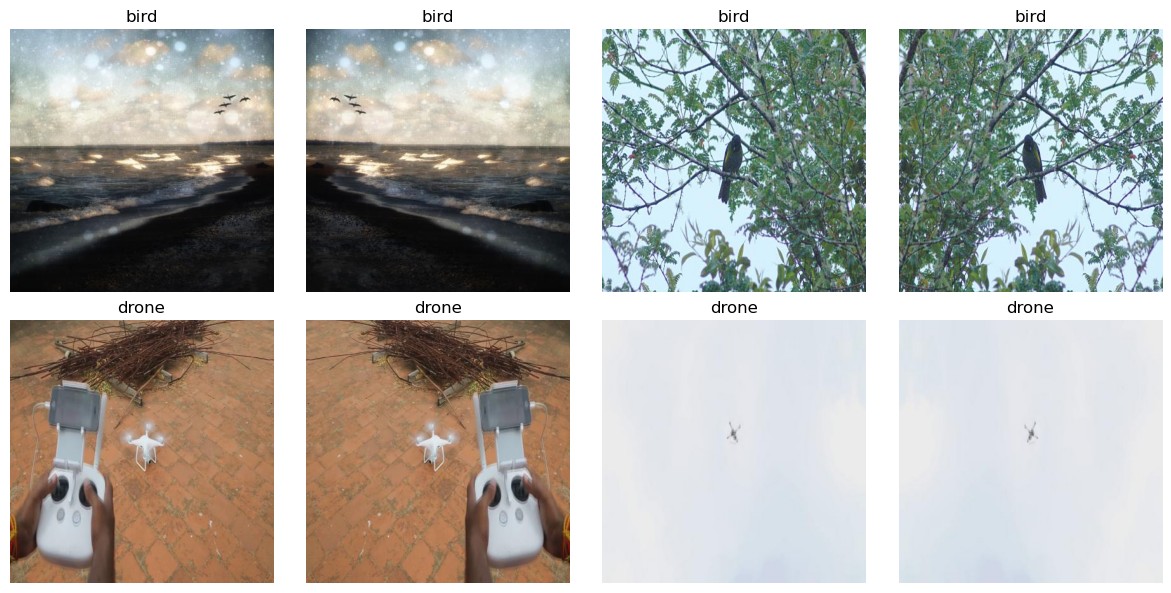

In [4]:
def show_samples(folder, n=4):
    classes = [c for c in os.listdir(folder) if os.path.isdir(os.path.join(folder, c))]
    fig, axes = plt.subplots(len(classes), n, figsize=(3*n, 3*len(classes)))
    for i, cls in enumerate(classes):
        cls_path = os.path.join(folder, cls)
        files = os.listdir(cls_path)[:n]
        for j, f in enumerate(files):
            img = plt.imread(os.path.join(cls_path, f))
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(cls)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR)


## 3. Data Preprocessing & Augmentation
- Resize to 224x224
- Custom CNN: rescale pixel values to [0,1]
- Transfer Learning: MobileNetV2 `preprocess_input`
- Augmentation: rotation, flip, zoom, brightness, shift/crop

In [5]:
# ---- Custom CNN generators (rescale to [0,1]) ----
train_gen_cnn = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)
valid_test_gen_cnn = ImageDataGenerator(rescale=1./255)

train_data_cnn = train_gen_cnn.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=CLASS_NAMES, seed=SEED
)
valid_data_cnn = valid_test_gen_cnn.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=CLASS_NAMES, shuffle=False
)
test_data_cnn = valid_test_gen_cnn.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=CLASS_NAMES, shuffle=False
)

print("Class indices:", train_data_cnn.class_indices)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class indices: {'bird': 0, 'drone': 1}


In [6]:
# ---- Transfer Learning generators (MobileNetV2 preprocess_input) ----
train_gen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)
valid_test_gen_tl = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data_tl = train_gen_tl.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=CLASS_NAMES, seed=SEED
)
valid_data_tl = valid_test_gen_tl.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=CLASS_NAMES, shuffle=False
)
test_data_tl = valid_test_gen_tl.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", classes=CLASS_NAMES, shuffle=False
)


Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


## 4. Model Building — Custom CNN
Conv layers + BatchNorm + MaxPooling + Dropout + Dense (sigmoid output for binary classification).

In [7]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                   loss="binary_crossentropy",
                   metrics=["accuracy"])
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()


c:\Users\relan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Model Building — Transfer Learning (MobileNetV2)
Load MobileNetV2 (ImageNet weights), freeze base, add custom head. A fine-tuned variant unfreezes the last 30 layers.

In [8]:
def build_transfer_model(input_shape=(224, 224, 3), fine_tune=False):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base_model.trainable = fine_tune

    if fine_tune:
        for layer in base_model.layers[:-30]:
            layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid")
    ])

    lr = 1e-5 if fine_tune else 1e-4
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                   loss="binary_crossentropy",
                   metrics=["accuracy"])
    return model

tl_model = build_transfer_model(fine_tune=False)
tl_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

## 6. Model Training
- Train Custom CNN and Transfer Learning models
- `EarlyStopping` + `ModelCheckpoint`
- Optional fine-tuning pass on the transfer learning model

In [9]:
EPOCHS = 10

cnn_callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("models/custom_cnn_best.h5", monitor="val_accuracy",
                     save_best_only=True, verbose=1)
]

history_cnn = cnn_model.fit(
    train_data_cnn,
    validation_data=valid_data_cnn,
    epochs=EPOCHS,
    callbacks=cnn_callbacks
)


c:\Users\relan\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6615 - loss: 0.6356
Epoch 1: val_accuracy improved from -inf to 0.49095, saving model to models/custom_cnn_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 366s 4s/step - accuracy: 0.6621 - loss: 0.6347 - val_accuracy: 0.4910 - val_loss: 0.6929
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7628 - loss: 0.4968
Epoch 2: val_accuracy did not improve from 0.49095
84/84 ━━━━━━━━━━━━━━━━━━━━ 274s 3s/step - accuracy: 0.7629 - loss: 0.4967 - val_accuracy: 0.4910 - val_loss: 0.7292
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7717 - loss: 0.4542
Epoch 3: val_accuracy did not improve from 0.49095
84/84 ━━━━━━━━━━━━━━━━━━━━ 274s 3s/step - accuracy: 0.7718 - loss: 0.4542 - val_accuracy: 0.4910 - val_loss: 0.8664
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7920 - loss: 0.4364
Epoch 4: val_accuracy did not improve from 0.49095
84/84 ━━━━━━━━━━━━━━━━━━━━ 289s 3s/step - accuracy: 0.7921 - loss: 0.4363 - val_accuracy: 0.4910 - val_loss: 0.9987


In [10]:
tl_callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("models/transfer_mobilenetv2_best.h5", monitor="val_accuracy",
                     save_best_only=True, verbose=1)
]

history_tl = tl_model.fit(
    train_data_tl,
    validation_data=valid_data_tl,
    epochs=EPOCHS,
    callbacks=tl_callbacks
)


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7257 - loss: 0.5879
Epoch 1: val_accuracy improved from -inf to 0.94118, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 798s 9s/step - accuracy: 0.7269 - loss: 0.5856 - val_accuracy: 0.9412 - val_loss: 0.1869
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9253 - loss: 0.1959
Epoch 2: val_accuracy improved from 0.94118 to 0.95928, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9254 - loss: 0.1957 - val_accuracy: 0.9593 - val_loss: 0.1277
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9424 - loss: 0.1535
Epoch 3: val_accuracy improved from 0.95928 to 0.96154, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9424 - loss: 0.1533 - val_accuracy: 0.9615 - val_loss: 0.1035
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9542 - loss: 0.1220
Epoch 4: val_accuracy improved from 0.96154 to 0.97059, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9542 - loss: 0.1220 - val_accuracy: 0.9706 - val_loss: 0.0895
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9682 - loss: 0.0890
Epoch 5: val_accuracy did not improve from 0.97059
84/84 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.9682 - loss: 0.0890 - val_accuracy: 0.9661 - val_loss: 0.0808
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9672 - loss: 0.0873
Epoch 6: val_accuracy did not improve from 0.97059
84/84 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9672 - loss: 0.0873 - val_accuracy: 0.9706 - val_loss: 0.0796
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9795 - loss: 0.0691
Epoch 7: val_accuracy improved from 0.97059 to 0.97285, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9795 - loss: 0.0692 - val_accuracy: 0.9729 - val_loss: 0.0779
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9814 - loss: 0.0630
Epoch 8: val_accuracy improved from 0.97285 to 0.97511, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9814 - loss: 0.0631 - val_accuracy: 0.9751 - val_loss: 0.0737
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9780 - loss: 0.0611
Epoch 9: val_accuracy improved from 0.97511 to 0.97738, saving model to models/transfer_mobilenetv2_best.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9780 - loss: 0.0611 - val_accuracy: 0.9774 - val_loss: 0.0756
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9808 - loss: 0.0677
Epoch 10: val_accuracy did not improve from 0.97738
84/84 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.9808 - loss: 0.0677 - val_accuracy: 0.9774 - val_loss: 0.0766


In [11]:
# Optional fine-tuning pass
tl_model_ft = build_transfer_model(fine_tune=True)
tl_model_ft.set_weights(tl_model.get_weights())

ft_callbacks = [
    EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    ModelCheckpoint("models/transfer_mobilenetv2_finetuned.h5", monitor="val_accuracy",
                     save_best_only=True, verbose=1)
]

history_ft = tl_model_ft.fit(
    train_data_tl,
    validation_data=valid_data_tl,
    epochs=5,
    callbacks=ft_callbacks
)


Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9479 - loss: 0.1176
Epoch 1: val_accuracy improved from -inf to 0.96833, saving model to models/transfer_mobilenetv2_finetuned.h5


84/84 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.9480 - loss: 0.1175 - val_accuracy: 0.9683 - val_loss: 0.0871
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9694 - loss: 0.0926
Epoch 2: val_accuracy did not improve from 0.96833
84/84 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.9694 - loss: 0.0925 - val_accuracy: 0.9638 - val_loss: 0.0968
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9597 - loss: 0.0964
Epoch 3: val_accuracy did not improve from 0.96833
84/84 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9598 - loss: 0.0963 - val_accuracy: 0.9593 - val_loss: 0.1065


## 7. Model Evaluation
- Accuracy / loss curves
- Confusion matrix & classification report (Precision, Recall, F1)

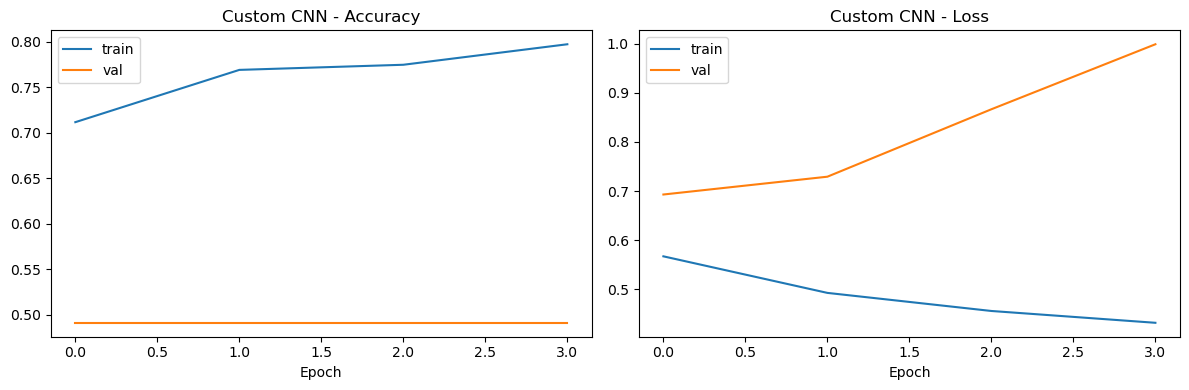

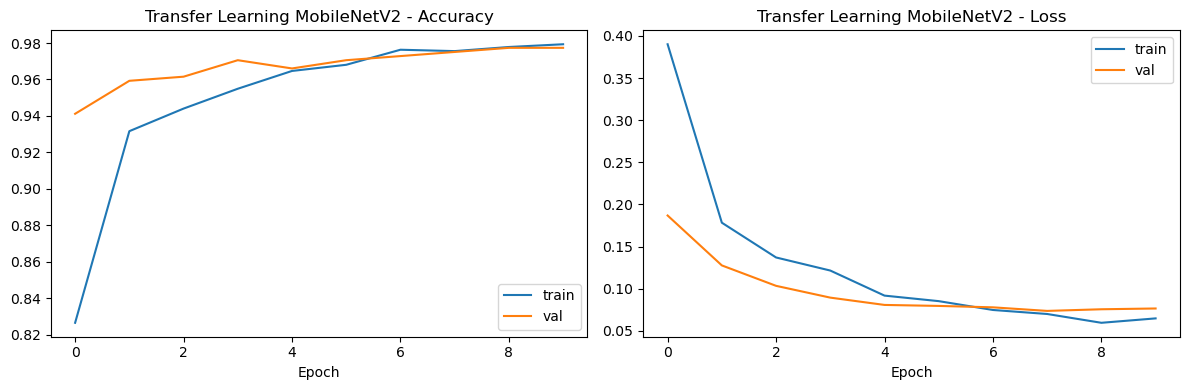

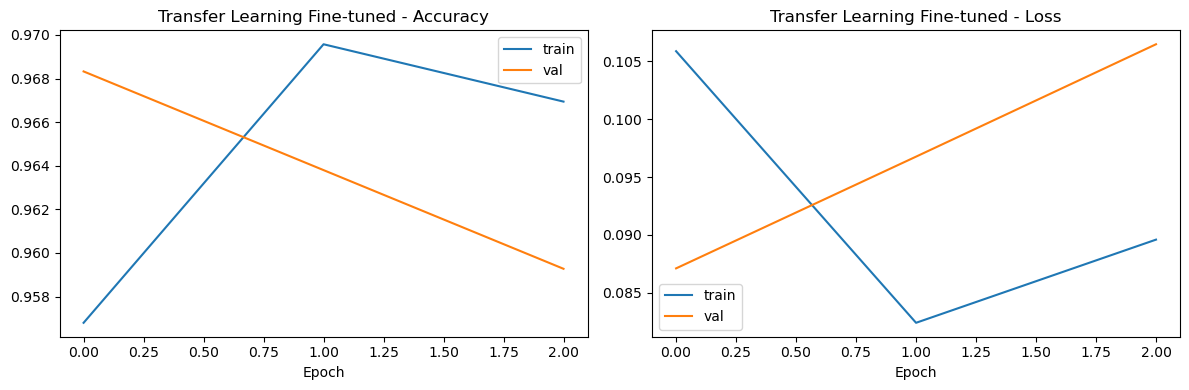

In [12]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Custom CNN")
plot_history(history_tl, "Transfer Learning MobileNetV2")
plot_history(history_ft, "Transfer Learning Fine-tuned")


7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 908ms/step
=== Custom CNN ===
              precision    recall  f1-score   support

        bird       0.56      1.00      0.72       121
       drone       0.00      0.00      0.00        94

    accuracy                           0.56       215
   macro avg       0.28      0.50      0.36       215
weighted avg       0.32      0.56      0.41       215



c:\Users\relan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\relan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\relan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


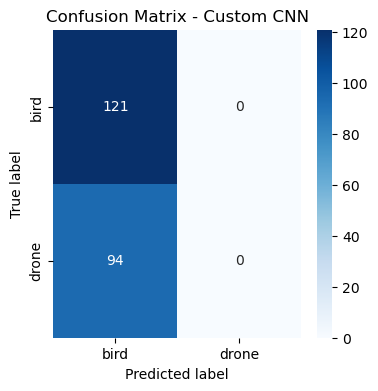

Test Accuracy: 0.5628 | Test Loss: 0.6865


c:\Users\relan\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step 
=== Transfer Learning MobileNetV2 ===
              precision    recall  f1-score   support

        bird       0.99      0.99      0.99       121
       drone       0.99      0.99      0.99        94

    accuracy                           0.99       215
   macro avg       0.99      0.99      0.99       215
weighted avg       0.99      0.99      0.99       215



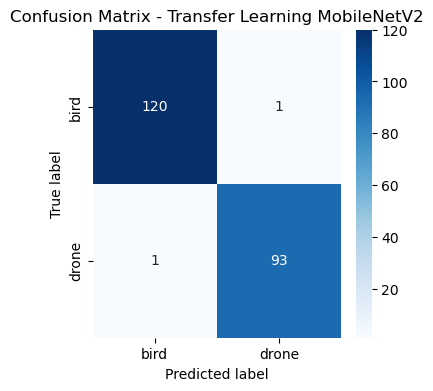

Test Accuracy: 0.9907 | Test Loss: 0.0452


7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step 
=== Transfer Learning Fine-tuned ===
              precision    recall  f1-score   support

        bird       0.99      0.95      0.97       121
       drone       0.94      0.99      0.96        94

    accuracy                           0.97       215
   macro avg       0.97      0.97      0.97       215
weighted avg       0.97      0.97      0.97       215



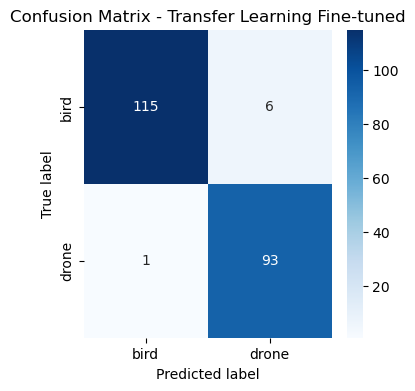

Test Accuracy: 0.9674 | Test Loss: 0.0527


In [13]:
def evaluate_model(model, test_data, title):
    test_data.reset()
    y_true = test_data.classes
    y_prob = model.predict(test_data).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f"=== {title} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix - {title}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
    return test_acc

acc_cnn = evaluate_model(cnn_model, test_data_cnn, "Custom CNN")
acc_tl  = evaluate_model(tl_model, test_data_tl, "Transfer Learning MobileNetV2")
acc_ft  = evaluate_model(tl_model_ft, test_data_tl, "Transfer Learning Fine-tuned")


## 8. Model Comparison & Save Best Model
Compare test accuracy across all three models, save a comparison report, and copy the best-performing model to `models/best_model.h5` for the Streamlit app.

                           Model  Test Accuracy
0  Transfer Learning MobileNetV2       0.990698
1   Transfer Learning Fine-tuned       0.967442
2                     Custom CNN       0.562791


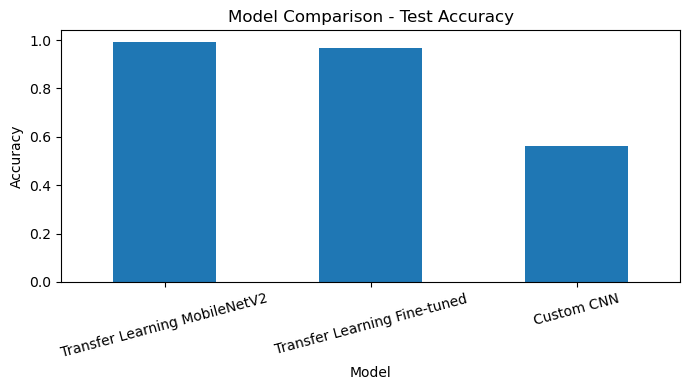

In [14]:
comparison = pd.DataFrame({
    "Model": ["Custom CNN", "Transfer Learning MobileNetV2", "Transfer Learning Fine-tuned"],
    "Test Accuracy": [acc_cnn, acc_tl, acc_ft]
}).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

print(comparison)

comparison.plot(x="Model", y="Test Accuracy", kind="bar", legend=False, figsize=(7, 4))
plt.title("Model Comparison - Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

comparison.to_csv("model_comparison_report.csv", index=False)


In [15]:
best_model_name = comparison.iloc[0]["Model"]
print("Best model:", best_model_name)

model_file_map = {
    "Custom CNN": "models/custom_cnn_best.h5",
    "Transfer Learning MobileNetV2": "models/transfer_mobilenetv2_best.h5",
    "Transfer Learning Fine-tuned": "models/transfer_mobilenetv2_finetuned.h5",
}

best_path = model_file_map[best_model_name]
shutil.copy(best_path, "models/best_model.h5")

with open("models/best_model_info.txt", "w") as f:
    f.write(best_model_name + "\n")
    if "Transfer" in best_model_name:
        f.write("preprocess: mobilenet_v2\n")
    else:
        f.write("preprocess: rescale_1_255\n")

print("Best model saved to models/best_model.h5")


Best model: Transfer Learning MobileNetV2
Best model saved to models/best_model.h5


## 9. Next Step
Run the Streamlit app:
```bash
streamlit run app.py
```
It will load `models/best_model.h5` and let you upload an image to get a Bird/Drone prediction with confidence score.